# Задание 1 (Вариант 4)


# Теоретический анализ

Независимые выборки с известными средними:

$\qquad 
X_1, \ldots X_n \sim N(\mu_1, \sigma_1^2)
$

$\qquad 
Y_1, \ldots Y_m \sim N(\mu_2, \sigma_2^2)
$

Строим оценки дисперсий по известным средним:

$\qquad 
S_X^2 = \frac{1}{n} \sum_{i=1}^n (X_i - \mu_1)^2
$

$\qquad
S_Y^2 = \frac{1}{m} \sum_{i=1}^m (Y_i - \mu_2)^2
$

Оцениваемый параметр:

$\qquad
\tau = \frac{\sigma_1^2}{\sigma_2^2}
$

Оценка:

$\qquad
\hat{\tau} = \frac{S_X^2}{S_Y^2}
$

### Распределение Фишера:

$\qquad
F = \frac{S_X^2 / \sigma_1^2}{S_Y^2 / \sigma_2^2} = \frac{\hat{\tau}}{\tau} \sim F(n, m)
$

$\qquad F(n, m)$ это распределение Фишера с $n$ и $m$ степенями свободы.

### Доверительный интервал уровня $1-\alpha$:

Пусть $F_{p}$ это квантиль уровня $p$ распределения Фишера $F(n, m)$. Тогда доверительный интервал для $\tau$:

$\qquad
\left[ \frac{\hat{\tau}}{F_{1-\alpha/2}}, \frac{\hat{\tau}}{F_{\alpha/2}} \right]
$

где:
- $F_{1-\alpha/2}$ — верхний квантиль (например, 97.5% при $\alpha=0.05$)
- $F_{\alpha/2}$ — нижний квантиль (например, 2.5% при $\alpha=0.05$)

### Если реальное значение $\tau$ попадает в этот интервал, то покрытие считается успешным.


## Импорты и параметры

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

np.random.seed(0)

MU_1, MU_2 = 0, 0
SSQ_1, SSQ_2 = 2, 1

TAU_TRUE = SSQ_1 / SSQ_2

ALPHA = 0.05

ITERATIONS = 1000


## Функция для проведения эксперимента

In [6]:
def experiment(n, m):
    covers = 0
    widths = []
    for _ in range(ITERATIONS):
        X = np.random.normal(MU_1, np.sqrt(SSQ_1), n)
        Y = np.random.normal(MU_2, np.sqrt(SSQ_2), m)
        S_X2 = np.mean((X - MU_1)**2)
        S_Y2 = np.mean((Y - MU_2)**2)
        tau_hat = S_X2 / S_Y2
        F_lower = f.ppf(ALPHA / 2, n, m)
        F_upper = f.ppf(1 - ALPHA / 2, n, m)
        ci_lower = tau_hat / F_upper
        ci_upper = tau_hat / F_lower
        widths.append(ci_upper - ci_lower)
        if ci_lower <= TAU_TRUE <= ci_upper:
            covers += 1
    coverage = covers / ITERATIONS
    avg_width = np.mean(widths)
    return coverage, avg_width


## Эксперимент

In [7]:
RESULTS = {}
for n in [25, 10000]:
    coverage, avg_width = experiment(n, n)
    RESULTS[n] = (coverage, avg_width)
    print(f'Размер выборки: {n}')
    print(f'Покрытие: {coverage:.6f}')
    print(f'Средняя ширина доверительного: {avg_width:.6f}')
    print()


Размер выборки: 25
Покрытие: 0.948000
Средняя ширина доверительного: 3.902799

Размер выборки: 10000
Покрытие: 0.963000
Средняя ширина доверительного: 0.156857

Размер выборки: 10000
Покрытие: 0.963000
Средняя ширина доверительного: 0.156857



## Визуализация

### Ширина интервала и покрытие в зависимости от размера выборки


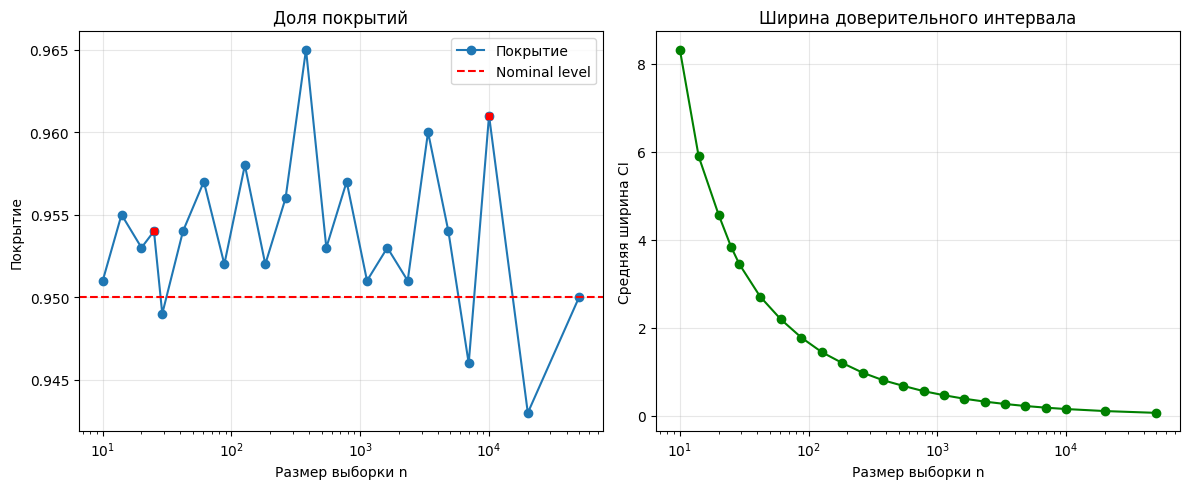

In [8]:
SIZES = np.logspace(1, 4, 20, dtype=int)
SIZES = np.unique(np.concatenate([
    SIZES,
    [25, 10000, 20000, 50000]
]))

coverages = []
widths = []

def plot():
    for n in SIZES:
        cov, w = experiment(n, n)
        coverages.append(cov)
        widths.append(w)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(SIZES, coverages, 'o-', label='Покрытие')
    plt.axhline(1-ALPHA, color='red', linestyle='--', label='Nominal level')
    plt.xlabel('Размер выборки n')
    plt.ylabel('Покрытие')
    plt.title('Доля покрытий')
    plt.xscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    for control_n in [25, 10000]:
        idx = np.where(SIZES == control_n)[0][0]
        plt.plot(control_n, coverages[idx], 's', color='red', markersize=5)

    plt.subplot(1, 2, 2)
    plt.plot(SIZES, widths, 'o-g', label='Ширина CI')
    plt.xlabel('Размер выборки n')
    plt.ylabel('Средняя ширина CI')
    plt.title('Ширина доверительного интервала')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

plot()


## Почему покрытие не всегда стабилизируется при больших n?

- Теоретически, при $n, m \to \infty$ покрытие доверительного интервала должно стремиться к $1-\alpha$ по закону больших чисел и свойствам $F$-распределения.

- На практике, при конечном числе повторов и очень больших $n$ возможны флуктуации покрытия из-за:
    - Смещённости оценки дисперсии (деление на $n$ вместо $n-1$).
    - Численных ошибок и ограниченной точности вычислений.
    - Особенностей генератора случайных чисел.

- Поэтому на графике покрытие может немного скакать и не стабилизироваться идеально на уровне $1-\alpha$.

### Вывод:
В реальных вычислениях покрытие может отклоняться от теоретического значения из-за численных и статистических эффектов, но при увеличении числа повторов и аккуратной реализации оно должно приближаться к $1-\alpha$.